In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
import os
print("Current working directory:", os.getcwd())

Current working directory: C:\Users\Dell\Desktop\inventory-optimization-project\notebooks


In [19]:
import os
os.chdir(r"C:\Users\Dell\Desktop\inventory-optimization-project\notebooks")
print("New working directory:", os.getcwd())
print(os.listdir("../data/raw/"))

New working directory: C:\Users\Dell\Desktop\inventory-optimization-project\notebooks
['begin_inventory.csv', 'end_inventory.csv', 'invoice_purchases.csv', 'price.csv', 'purchases.csv', 'sales.csv']


In [20]:
DATA_PATH = "../data/raw/"
sales_df = pd.read_csv(DATA_PATH + "sales.csv")

In [21]:
sales_df['SalesDate'].dtype

dtype('O')

In [22]:
sales_df.head()

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,1/1/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,1/2/2016,750,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,1/3/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,1/8/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,1/9/2016,375,1,0.79,12546,JIM BEAM BRANDS COMPANY


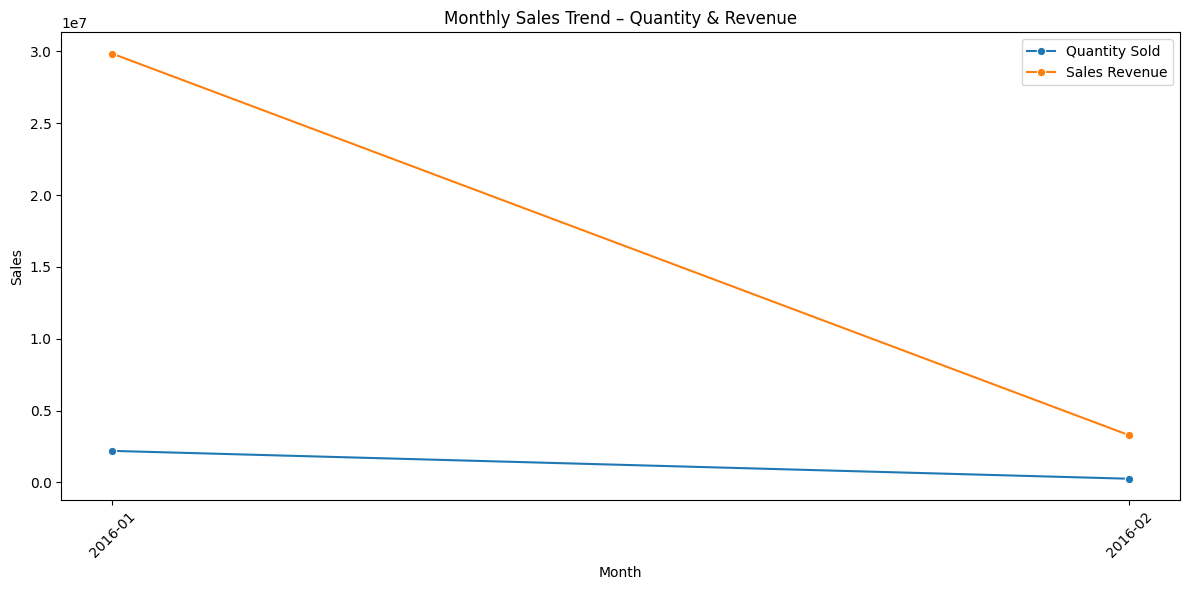

In [37]:
# Convert SalesDate to datetime
sales_df['SalesDate'] = pd.to_datetime(
    sales_df['SalesDate'],
    errors='coerce'
)

# Create YearMonth column
sales_df['YearMonth'] = sales_df['SalesDate'].dt.to_period('M')

# Aggregate monthly sales
monthly_sales = sales_df.groupby('YearMonth').agg({
    'SalesQuantity': 'sum',
    'SalesDollars': 'sum'
}).reset_index()

# Convert YearMonth to string for plotting
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

# Plot monthly sales trends
plt.figure(figsize=(12,6))
sns.lineplot(
    x='YearMonth',
    y='SalesQuantity',
    data=monthly_sales,
    marker='o',
    label='Quantity Sold'
)
sns.lineplot(
    x='YearMonth',
    y='SalesDollars',
    data=monthly_sales,
    marker='o',
    label='Sales Revenue'
)
##the title, x and y axis
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend – Quantity & Revenue")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


PT1. INVENTORY OPTIMIZATION ABOVE.

In [29]:
# Aggregate sales by Store
store_performance = sales_df.groupby('Store').agg({
    'SalesQuantity': 'sum',
    'SalesDollars': 'sum'
}).reset_index()

# Sort by total sales revenue (descending)
store_performance = store_performance.sort_values(
    by='SalesDollars',
    ascending=False
)

# Take top 10 and add ranking column
top_10_stores = store_performance.head(10).reset_index(drop=True)
top_10_stores['Rank'] = top_10_stores.index + 1

# Reorder columns for readability
top_10_stores = top_10_stores[['Rank', 'Store', 'SalesQuantity', 'SalesDollars']]

top_10_stores


,Rank,Store,SalesQuantity,SalesDollars
0,1,34,99171,1537806.51
1,2,15,101078,1422998.94
2,3,76,85724,1402698.59
3,4,73,77848,1266850.62
4,5,66,76814,1257824.93
5,6,38,84965,1237991.19
6,7,10,91576,1154926.80
7,8,69,73741,1131369.88
8,9,67,66678,1117046.85
9,10,1,82750,975115.86


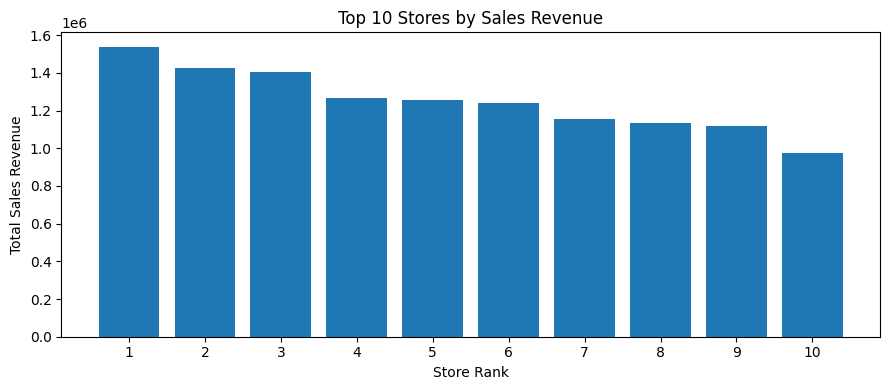

In [39]:
plt.figure(figsize=(9,4)) 

plt.bar(
    top_10_stores['Rank'],
    top_10_stores['SalesDollars']
)

plt.title("Top 10 Stores by Sales Revenue")
plt.xlabel("Store Rank")
plt.ylabel("Total Sales Revenue")
plt.xticks(top_10_stores['Rank'])

plt.tight_layout()
plt.show()

### Store-wise Performance Insights

- A small number of stores contribute a significant portion of total sales revenue.
- High-performing stores should be prioritized for inventory replenishment to avoid stockouts.
- Low-performing stores may require tighter inventory control to prevent overstocking.
- Store-level performance insights will be used later to customize reorder points.


In [47]:
product_performance = sales_df.groupby(
    ['Brand', 'Description', 'Size']
).agg({
    'SalesQuantity': 'sum',
    'SalesDollars': 'sum'
}).reset_index()

product_performance = product_performance.sort_values(
    by='SalesDollars',
    ascending=False
)
top_10_products = product_performance.head(10).reset_index(drop=True)
top_10_products['Rank'] = top_10_products.index + 1

top_10_products = top_10_products[
    ['Rank', 'Brand', 'Description', 'Size', 'SalesQuantity', 'SalesDollars']
]

top_10_products

,Rank,Brand,Description,Size,SalesQuantity,SalesDollars
0,1,4261,Capt Morgan Spiced Rum,1.75L,20226,444810.74
1,2,3545,Ketel One Vodka,1.75L,11883,357759.17
2,3,1233,Jack Daniels No 7 Black,1.75L,9578,344712.22
3,4,8068,Absolut 80 Proof,1.75L,11189,288135.11
4,5,3405,Tito's Handmade Vodka,1.75L,9203,275162.97
5,6,3858,Grey Goose Vodka,750mL,9378,225014.22
6,7,2589,Jameson Irish Whiskey,1.75L,4649,191669.51
7,8,4227,Bacardi Superior Rum Trav,1.75L,10209,183659.91
8,9,1376,Jim Beam,1.75L,7362,169922.38
9,10,2585,Jameson Irish Whiskey,750mL,6940,164426.60


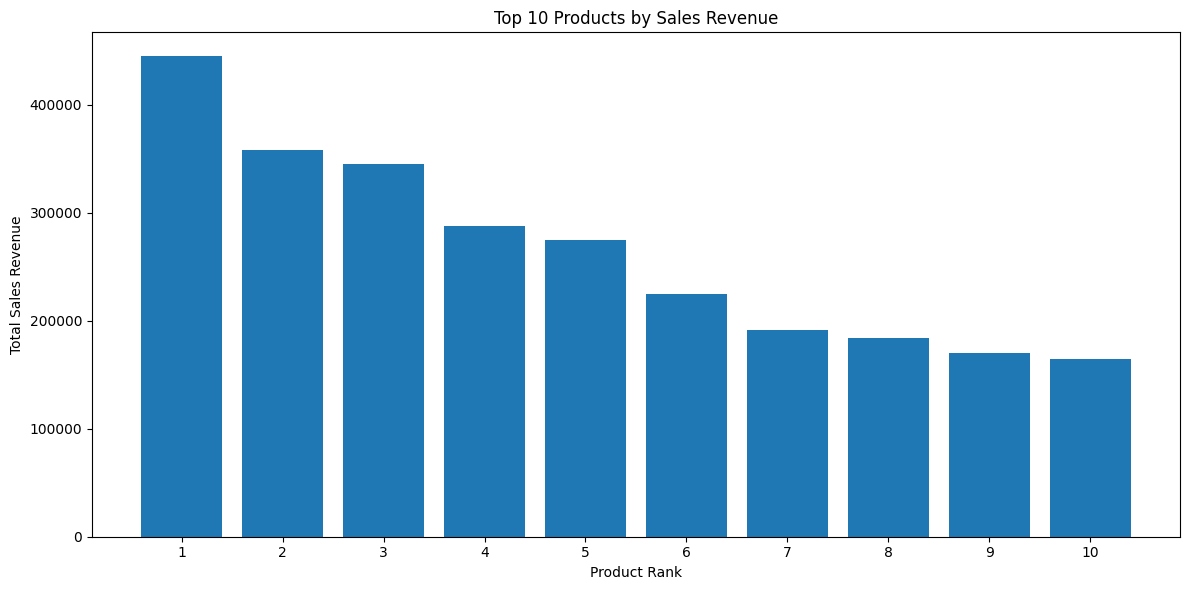

In [48]:
plt.figure(figsize=(12,6))

plt.bar(
    top_10_products['Rank'],
    top_10_products['SalesDollars']
)

plt.title("Top 10 Products by Sales Revenue")
plt.xlabel("Product Rank")
plt.ylabel("Total Sales Revenue")
plt.xticks(top_10_products['Rank'])

plt.tight_layout()
plt.show()

### Product-wise Performance Insights

- A small subset of products contributes a large portion of total sales revenue.
- High-performing products should be classified as high-priority inventory.
- Low-performing products can be managed with leaner stock levels to reduce holding costs.
- These insights will be used in the next step for ABC inventory classification.

In [ ]:
ABC ANALYSIS

In [60]:
# Aggregate sales at product level
abc_df = sales_df.groupby(
    ['Brand', 'Description', 'Size']
).agg({
    'SalesQuantity': 'sum',
    'SalesDollars': 'sum'
}).reset_index()

abc_df = abc_df.sort_values(
    by='SalesDollars',
    ascending=False
).reset_index(drop=True)

# Total sales value
total_sales_value = abc_df['SalesDollars'].sum()

# Percentage contribution of each product
abc_df['SalesPercent'] = abc_df['SalesDollars'] / total_sales_value * 100

# Cumulative percentage
abc_df['CumulativeSalesPercent'] = abc_df['SalesPercent'].cumsum()

def abc_classification(cum_percent):
    if cum_percent <= 70:
        return 'A'
    elif cum_percent <= 90:
        return 'B'
    else:
        return 'C'

abc_df['ABC_Category'] = abc_df['CumulativeSalesPercent'].apply(abc_classification)

abc_df.head(10) ##shows only A since arranged in descending order. HIGH SALES PRODUCTS.





,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPercent,CumulativeSalesPercent,ABC_Category
0,4261,Capt Morgan Spiced Rum,1.75L,20226,444810.74,1.342242,1.342242,A
1,3545,Ketel One Vodka,1.75L,11883,357759.17,1.079559,2.421802,A
2,1233,Jack Daniels No 7 Black,1.75L,9578,344712.22,1.040189,3.461991,A
3,8068,Absolut 80 Proof,1.75L,11189,288135.11,0.869465,4.331455,A
4,3405,Tito's Handmade Vodka,1.75L,9203,275162.97,0.830320,5.161776,A
5,3858,Grey Goose Vodka,750mL,9378,225014.22,0.678994,5.840769,A
6,2589,Jameson Irish Whiskey,1.75L,4649,191669.51,0.578374,6.419143,A
7,4227,Bacardi Superior Rum Trav,1.75L,10209,183659.91,0.554205,6.973348,A
8,1376,Jim Beam,1.75L,7362,169922.38,0.512751,7.486098,A
9,2585,Jameson Irish Whiskey,750mL,6940,164426.60,0.496167,7.982265,A


In [56]:
abc_df['ABC_Category'].value_counts()

ABC_Category
C    5239
B    1444
A     975
Name: count, dtype: int64

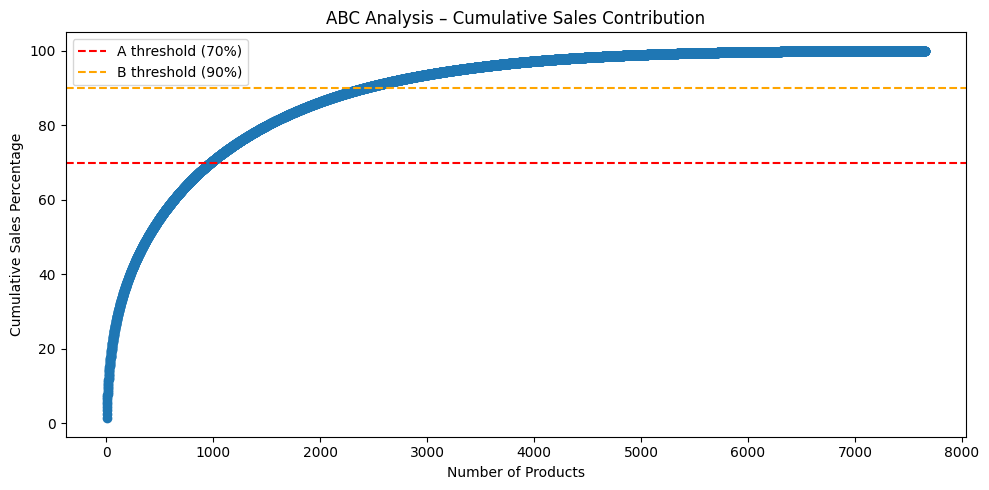

In [61]:
plt.figure(figsize=(10,5))

plt.plot(
    abc_df.index + 1,
    abc_df['CumulativeSalesPercent'],
    marker='o'
)

plt.axhline(70, color='red', linestyle='--', label='A threshold (70%)')
plt.axhline(90, color='orange', linestyle='--', label='B threshold (90%)')

plt.title("ABC Analysis – Cumulative Sales Contribution")
plt.xlabel("Number of Products")
plt.ylabel("Cumulative Sales Percentage")
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
# INVENTORY MAPPING:
inventory_strategy = {
    'A': {
        'Review_Frequency': 'Weekly',
        'Safety_Stock_Level': 'High',
        'Control_Strategy': 'Tight control, frequent replenishment'
    },
    'B': {
        'Review_Frequency': 'Monthly',
        'Safety_Stock_Level': 'Medium',
        'Control_Strategy': 'Moderate control'
    },
    'C': {
        'Review_Frequency': 'Quarterly',
        'Safety_Stock_Level': 'Low',
        'Control_Strategy': 'Simple control, bulk ordering'
    }
}

# CONVERTING TO DATAFRAME
strategy_df = pd.DataFrame.from_dict(
    inventory_strategy,
    orient='index'
).reset_index()

strategy_df.rename(columns={'index': 'ABC_Category'}, inplace=True)

strategy_df

,ABC_Category,Review_Frequency,Safety_Stock_Level,Control_Strategy
0,A,Weekly,High,"Tight control, frequent replenishment"
1,B,Monthly,Medium,Moderate control
2,C,Quarterly,Low,"Simple control, bulk ordering"


Inventory control strategies were customized. 
Category A items require tight control and frequent review due to their high revenue impact, 
Category C items are managed using relaxed controls to reduce administrative overhead.

In [67]:
# Calculate annual demand per product
annual_demand = sales_df.groupby(
    ['Brand', 'Description', 'Size']
).agg({
    'SalesQuantity': 'sum'
}).reset_index()

annual_demand.rename(
    columns={'SalesQuantity': 'Annual_Demand'},
    inplace=True
)
annual_demand.head()

,Brand,Description,Size,Annual_Demand
0,58,Gekkeikan Black & Gold Sake,750mL,288
1,60,Canadian Club 1858 VAP,750mL,124
2,61,Margaritaville Silver,750mL,24
3,62,Herradura Silver Tequila,750mL,162
4,63,Herradura Reposado Tequila,750mL,131


In [81]:
DATA_PATH = "../data/raw/"
sales_df = pd.read_csv(DATA_PATH + "sales.csv")
price_df = pd.read_csv(DATA_PATH + "price.csv")
##remove duplicates.
price_df = price_df.drop_duplicates(subset=['Brand','Description','Size'], keep='first')
eoq_df = annual_demand.merge(price_df, on=['Brand','Description','Size'], how='left')

In [82]:
price_df.columns = price_df.columns.str.strip()
sales_df.columns = sales_df.columns.str.strip()

#Keep only required columns from price_df
price_df = price_df[['Brand', 'Description', 'Size', 'PurchasePrice']]

#Calculate annual demand per product from sales
annual_demand = sales_df.groupby(['Brand', 'Description', 'Size']).agg({
    'SalesQuantity': 'sum'
}).reset_index()
annual_demand.rename(columns={'SalesQuantity': 'Annual_Demand'}, inplace=True)

#Merge annual demand with purchase price
eoq_df = annual_demand.merge(
    price_df,
    on=['Brand', 'Description', 'Size'],
    how='left'
)

#Define EOQ parameters
ORDERING_COST = 500           # Example cost per order
HOLDING_COST_RATE = 0.20      # 20% of unit cost per year
eoq_df['Holding_Cost'] = eoq_df['PurchasePrice'] * HOLDING_COST_RATE

#Calculate EOQ
eoq_df['EOQ'] = np.sqrt((2 * eoq_df['Annual_Demand'] * ORDERING_COST) / eoq_df['Holding_Cost'])

Clean EOQ values (remove inf or NaN)
eoq_df = eoq_df.replace([np.inf, -np.inf], np.nan)
eoq_df = eoq_df.dropna(subset=['EOQ'])

#View top 10 EOQ results
print(eoq_df[['Brand', 'Description', 'Size', 'Annual_Demand', 'PurchasePrice', 'EOQ']].head(10))

   Brand                   Description   Size  Annual_Demand  PurchasePrice  \
0     58   Gekkeikan Black & Gold Sake  750mL            288           9.28   
1     60        Canadian Club 1858 VAP  750mL            124           7.40   
2     61         Margaritaville Silver  750mL             24          10.60   
3     62      Herradura Silver Tequila  750mL            162          28.67   
4     63    Herradura Reposado Tequila  750mL            131          30.46   
5     72          No. 3 London Dry Gin  750mL             19          26.11   
6     75     Three Olives Tomato Vodka  750mL              3          10.94   
7     77   Three Olives Espresso Vodka  750mL            908          10.39   
8     79      Three Olives Loopy Vodka  750mL            416           9.62   
9     82  Hundred Acre Ark Vy Cab Svgn  750mL              3         248.34   

          EOQ  
0  393.919299  
1  289.454286  
2  106.399035  
3  168.084886  
4  146.641097  
5   60.319588  
6   37.028572  
7 

In [87]:
# Merge ABC into EOQ dataframe
eoq_abc_df = eoq_df.merge(
    abc_df[['Brand', 'Description', 'Size', 'ABC_Category']],
    on=['Brand', 'Description', 'Size'],
    how='left'
)

# Check merge
eoq_abc_df.head(10)

,Brand,Description,Size,Annual_Demand,PurchasePrice,Holding_Cost,EOQ,ABC_Category
0,58,Gekkeikan Black & Gold Sake,750mL,288,9.28,1.856,393.919299,B
1,60,Canadian Club 1858 VAP,750mL,124,7.40,1.480,289.454286,C
2,61,Margaritaville Silver,750mL,24,10.60,2.120,106.399035,C
3,62,Herradura Silver Tequila,750mL,162,28.67,5.734,168.084886,B
4,63,Herradura Reposado Tequila,750mL,131,30.46,6.092,146.641097,B
5,72,No. 3 London Dry Gin,750mL,19,26.11,5.222,60.319588,C
6,75,Three Olives Tomato Vodka,750mL,3,10.94,2.188,37.028572,C
7,77,Three Olives Espresso Vodka,750mL,908,10.39,2.078,661.028452,A
8,79,Three Olives Loopy Vodka,750mL,416,9.62,1.924,464.990555,B
9,82,Hundred Acre Ark Vy Cab Svgn,750mL,3,248.34,49.668,7.771812,C


In [89]:
final_df = eoq_abc_df.merge(
    strategy_df,
    on='ABC_Category',
    how='left'
)

# Optional: rename for clarity
final_df.rename(columns={'Control_Strategy': 'Inventory_Strategy'}, inplace=True)

# View top 10 rows
final_df[['Brand','Description','Size','Annual_Demand','PurchasePrice','EOQ','ABC_Category','Inventory_Strategy']].head(10)

,Brand,Description,Size,Annual_Demand,PurchasePrice,EOQ,ABC_Category,Inventory_Strategy
0,58,Gekkeikan Black & Gold Sake,750mL,288,9.28,393.919299,B,Moderate control
1,60,Canadian Club 1858 VAP,750mL,124,7.40,289.454286,C,"Simple control, bulk ordering"
2,61,Margaritaville Silver,750mL,24,10.60,106.399035,C,"Simple control, bulk ordering"
3,62,Herradura Silver Tequila,750mL,162,28.67,168.084886,B,Moderate control
4,63,Herradura Reposado Tequila,750mL,131,30.46,146.641097,B,Moderate control
5,72,No. 3 London Dry Gin,750mL,19,26.11,60.319588,C,"Simple control, bulk ordering"
6,75,Three Olives Tomato Vodka,750mL,3,10.94,37.028572,C,"Simple control, bulk ordering"
7,77,Three Olives Espresso Vodka,750mL,908,10.39,661.028452,A,"Tight control, frequent replenishment"
8,79,Three Olives Loopy Vodka,750mL,416,9.62,464.990555,B,Moderate control
9,82,Hundred Acre Ark Vy Cab Svgn,750mL,3,248.34,7.771812,C,"Simple control, bulk ordering"


In [90]:
final_df.to_csv("../data/processed/sales_inventory_plan.csv", index=False)

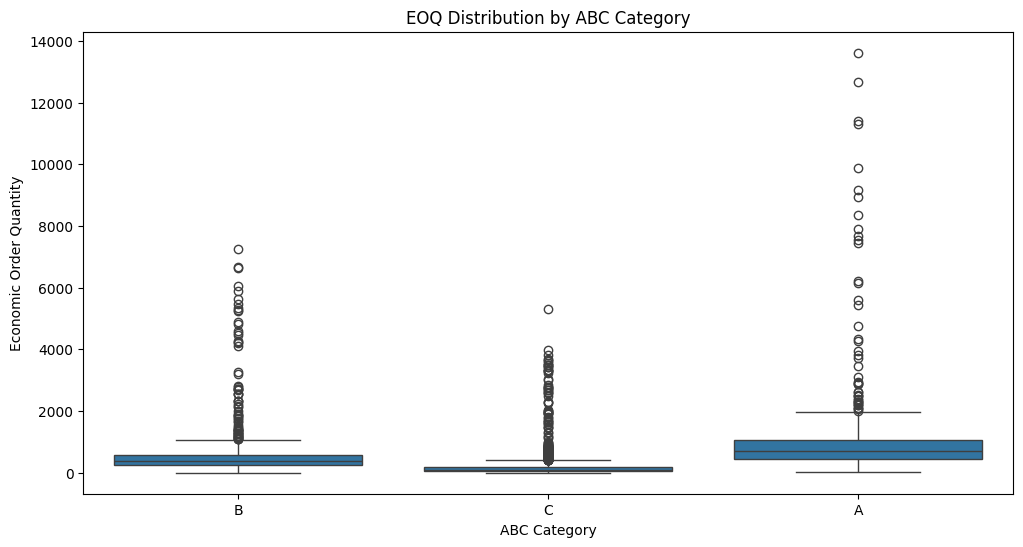

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(x='ABC_Category', y='EOQ', data=final_df)
plt.title('EOQ Distribution by ABC Category')
plt.ylabel('Economic Order Quantity')
plt.xlabel('ABC Category')
plt.show()


-This was ABC+EOQ+ INVENTORY STRATEGY 
-Above is inventory optimization table

In [118]:
purchase_df = pd.read_csv(DATA_PATH + "purchase.csv")

# Clean column names
purchase_df.columns = purchase_df.columns.str.strip()

print(purchase_df.columns.tolist())
purchase_df['PODate'] = pd.to_datetime(purchase_df['PODate'], errors='coerce')
purchase_df['InvoiceDate'] = pd.to_datetime(purchase_df['InvoiceDate'], errors='coerce')

# Lead time in days
purchase_df['LeadTime_Days'] = (
    purchase_df['InvoiceDate'] - purchase_df['PODate']
).dt.days

# Keep valid lead times only
purchase_df = purchase_df[purchase_df['LeadTime_Days'] >= 0]

purchase_df[['VendorName','PODate','InvoiceDate','LeadTime_Days']].head()


['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate', 'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval']


,VendorName,PODate,InvoiceDate,LeadTime_Days
0,ALTAMAR BRANDS LLC,2015-12-21,2016-01-04,14
1,AMERICAN VINTAGE BEVERAGE,2015-12-22,2016-01-07,16
2,ATLANTIC IMPORTING COMPANY,2015-12-24,2016-01-09,16
3,BACARDI USA INC,2015-12-20,2016-01-12,23
4,BANFI PRODUCTS CORP,2015-12-24,2016-01-07,14


In [119]:
lead_time_df = purchase_df.groupby(
    ['VendorNumber','VendorName']
).agg(
    Avg_LeadTime_Days=('LeadTime_Days','mean')
).reset_index()

lead_time_df.head()


,VendorNumber,VendorName,Avg_LeadTime_Days
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",16.500000
1,54,AAPER ALCOHOL & CHEMICAL CO,14.000000
2,60,ADAMBA IMPORTS INTL INC,16.485714
3,105,ALTAMAR BRANDS LLC,16.975000
4,200,AMERICAN SPIRITS EXCHANGE,18.833333


In [125]:
sales_df['SalesDate'] = pd.to_datetime(sales_df['SalesDate'], errors='coerce')

demand_df = sales_df.groupby(
    ['Brand','Description','Size']
).agg(
    Annual_Demand=('SalesQuantity','sum')
).reset_index()

demand_df['Avg_Daily_Demand'] = demand_df['Annual_Demand'] / 365
demand_df.head()


,Brand,Description,Size,Annual_Demand,Avg_Daily_Demand
0,58,Gekkeikan Black & Gold Sake,750mL,288,0.789041
1,60,Canadian Club 1858 VAP,750mL,124,0.339726
2,61,Margaritaville Silver,750mL,24,0.065753
3,62,Herradura Silver Tequila,750mL,162,0.443836
4,63,Herradura Reposado Tequila,750mL,131,0.358904


In [132]:
final_df['Avg_LeadTime_Days'] = lead_time_df['Avg_LeadTime_Days'].mean()


In [133]:
def safety_factor(abc):
    if abc == 'A':
        return 1.5
    elif abc == 'B':
        return 1.2
    else:
        return 1.0

final_df['Safety_Factor'] = final_df['ABC_Category'].apply(safety_factor)


In [134]:
final_df['Reorder_Point'] = (
    final_df['Avg_Daily_Demand'] *
    final_df['Avg_LeadTime_Days'] *
    final_df['Safety_Factor']
).round()


In [135]:
final_df[
    [
        'Brand',
        'Description',
        'Size',
        'ABC_Category',
        'Annual_Demand',
        'EOQ',
        'Avg_LeadTime_Days',
        'Reorder_Point',
        'Inventory_Strategy'
    ]
].head(10)


,Brand,Description,Size,ABC_Category,Annual_Demand,EOQ,Avg_LeadTime_Days,Reorder_Point,Inventory_Strategy
0,58,Gekkeikan Black & Gold Sake,750mL,B,288,393.919299,16.541054,16.0,Moderate control
1,60,Canadian Club 1858 VAP,750mL,C,124,289.454286,16.541054,6.0,"Simple control, bulk ordering"
2,61,Margaritaville Silver,750mL,C,24,106.399035,16.541054,1.0,"Simple control, bulk ordering"
3,62,Herradura Silver Tequila,750mL,B,162,168.084886,16.541054,9.0,Moderate control
4,63,Herradura Reposado Tequila,750mL,B,131,146.641097,16.541054,7.0,Moderate control
5,72,No. 3 London Dry Gin,750mL,C,19,60.319588,16.541054,1.0,"Simple control, bulk ordering"
6,75,Three Olives Tomato Vodka,750mL,C,3,37.028572,16.541054,0.0,"Simple control, bulk ordering"
7,77,Three Olives Espresso Vodka,750mL,A,908,661.028452,16.541054,62.0,"Tight control, frequent replenishment"
8,79,Three Olives Loopy Vodka,750mL,B,416,464.990555,16.541054,23.0,Moderate control
9,82,Hundred Acre Ark Vy Cab Svgn,750mL,C,3,7.771812,16.541054,0.0,"Simple control, bulk ordering"


In [136]:
sales_df['SalesDate'] = pd.to_datetime(sales_df['SalesDate'], errors='coerce')
sales_df['YearMonth'] = sales_df['SalesDate'].dt.to_period('M')

monthly_sales = sales_df.groupby('YearMonth').agg({
    'SalesQuantity': 'sum',
    'SalesDollars': 'sum'
}).reset_index()

monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)


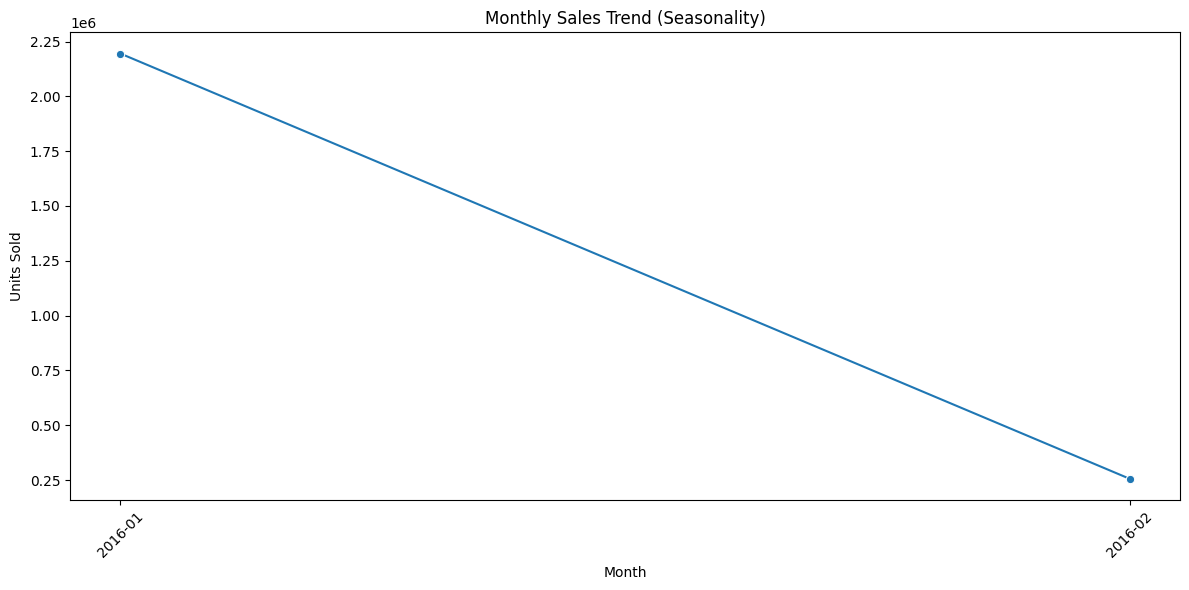

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.lineplot(x='YearMonth', y='SalesQuantity', data=monthly_sales, marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

In [139]:
location_sales = sales_df.groupby('Store').agg({
    'SalesQuantity': 'sum',
    'SalesDollars': 'sum'
}).reset_index()

top_stores = location_sales.sort_values(
    'SalesDollars', ascending=False
).head(10)

top_stores


,Store,SalesQuantity,SalesDollars
33,34,99171,1537806.51
14,15,101078,1422998.94
75,76,85724,1402698.59
72,73,77848,1266850.62
65,66,76814,1257824.93
37,38,84965,1237991.19
9,10,91576,1154926.80
68,69,73741,1131369.88
66,67,66678,1117046.85
0,1,82750,975115.86


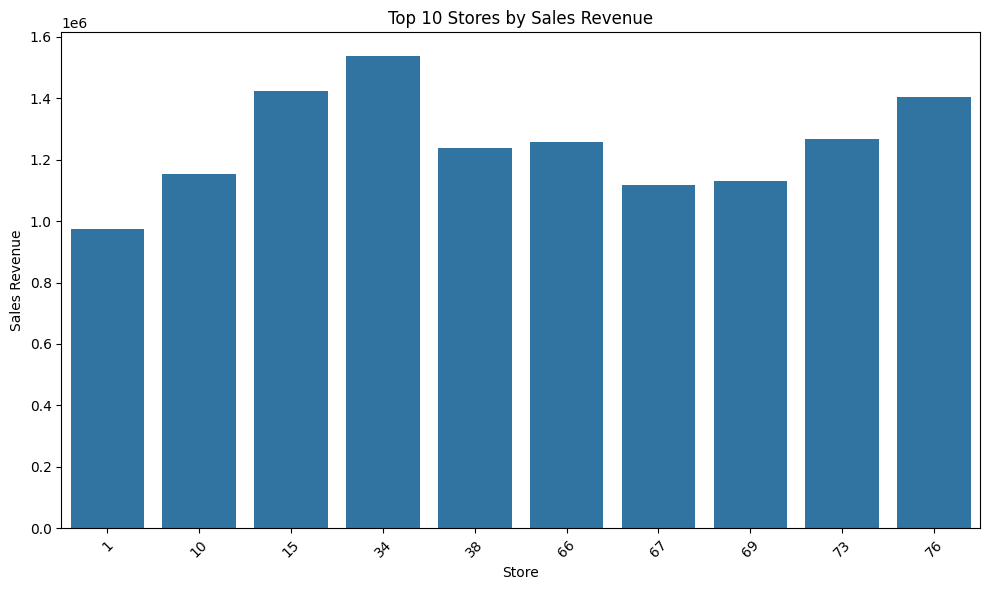

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x='Store', y='SalesDollars', data=top_stores)
plt.xticks(rotation=45)
plt.title("Top 10 Stores by Sales Revenue")
plt.ylabel("Sales Revenue")
plt.xlabel("Store")
plt.tight_layout()
plt.show()

In [143]:
final_df.to_csv(
    "../data/processed/final_inventory_optimization.csv",
    index=False
)


In [144]:
sales_df['SalesDate'] = pd.to_datetime(sales_df['SalesDate'], errors='coerce')
sales_df['YearMonth'] = sales_df['SalesDate'].dt.to_period('M')

monthly_sales = sales_df.groupby('YearMonth').agg({
    'SalesQuantity': 'sum',
    'SalesDollars': 'sum'
}).reset_index()

monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)


In [145]:
monthly_sales.to_csv(
    "../data/processed/monthly_sales_trends.csv",
    index=False
)


In [146]:
location_sales = sales_df.groupby('Store').agg({
    'SalesQuantity': 'sum',
    'SalesDollars': 'sum'
}).reset_index()
location_sales.to_csv(
    "../data/processed/store_performance.csv",
    index=False
)


In [147]:
import os
os.listdir("../data/processed")


['final_inventory_optimization.csv',
 'monthly_sales_trends.csv',
 'sales_inventory_plan.csv',
 'store_performance.csv']